# 3. The HBV model

In this chapter, the discharge of the Okavango River at Mohembo will be modelled. First, a model is selected based on similar studies of the river. Using similar studies, a hydrological model that is suitable for the Okavango River can be chosen. After the selection, the model will be calibrated and the result will be compared to the observed discharge data. 

## Model selection
Different hydrological models have been used in earlier research to model the Okavango River. One study in 2006 used the Pitman hydrological model to assess the impact of different climate change scenarios on the river flow (Andersson, et al., 2006). More recent studies use the Soil and Water Assessment Tool (SWAT) to model the Okavango River (Homa, et al., 2025; Negussie, et al., 2026). The eWaterCycle does not contain one these models, so for this study the Hydrologiska Bryåns Vattenbalansavdelning (HBV) model is chosen. The reason for this choice is the fact that the HBV model shares some similarities with the Pitman model. Like the Pitman model and SWAT, the HBV model is semi-distributed. Also, the processes that are used in the different models are similar. In figure 3.1, a schematic representation of the HBV model is given (Melotto, et al., 2026). The HBV model is a conceptual catchment model and it has a relatively simple model structure. Despite the simplicity of the model, the HBV model performed well during several model intercomparisons (Seibert & Bergström, 2022). The components of the HBV model with their description are given in table 3.1 (Melotto, et al., 2026).

<figure>
  <img src="Figures/HBV_model.png" width="400">
  <figcaption><i>Figure 3.1: Schematic representation HBV (Melotto, et al., 2026)</i></figcaption>
</figure>

|                        |**Inputs**               |**Description**                                |
|------------------------|-------------------------|-----------------------------------------------|
|**Reservoirs**          |Sp                       |Snow reservoir                                 |
|                        |Si                       |Interception reservoir                         |
|                        |Su                       |Unsaturated reservoir                          |
|                        |Sf                       |Fast reservoir                                 |
|                        |Ss                       |Slow reservoir                                 |
|**Inputs**              |P                        |Precipitation (mm/day)                         |
|                        |Ep                       |Potential evaporation (mm/day)                 |
|                        |T                        |Temperature (degree Celsius)                   |
|**Parameters**          |Imax                     |Interception capacity (mm)                     |
|                        |Ce                       |Soil runoff coefficient (-)                    |
|                        |Sumax                    |Max soil moisture storage (mm)                 |
|                        |Beta                     |Shape parameter for runoff generation (-)      |
|                        |Pmax                     |Percolation threshold (mm/day)                 |
|                        |Tlag                     |Routing lag time (days)                        |
|                        |Kf                       |Fast runoff recession coefficient (1/day)      |
|                        |Ks                       |Slow runoff recession coefficient (1/day)      |
|                        |Fm                       |Snowmelt factor (-)                            |

<div align="center">
<i>Table 3.1: Elaboration different components (Melotto, et al., 2026)</i>
</div>

## 3.2 Calibration
The precipitation, temperature and potential evaporation are the inputs for the HBV model. These inputs are retrieved from the ERA5 dataset. In the code below, the way to download the ERA5 forcing data is shown. To download the forcing data, a shapefile of the catchment area is needed. The shapefile for the catchment area of Mohembo is made with QGIS, using HydroBASINS of Africa (HydroSHEDS, n.d.). “HydroBASINS represents a series of vectorized polygon layers that depict sub-basin boundaries at a global scale” (HydroSHEDS, n.d.). With a picture of the catchment area of Mohembo, the sub-basins are selected in QGIS to make the shapefile (Bartsch, et al., 2006).      

In [1]:
#Loading packages
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

from scipy.stats import qmc

In [2]:
#Loading shapefile of the catchment area of Mohembo
shapefile_path =  Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/Shapefile" / "CatchmentArea_4326.shp"

#Defining start and end date for ERA5 data
start_date = "1970-01-01T00:00:00Z"
end_date = "2020-12-31T00:00:00Z"

#Creating path for ERA5 data
forcing_path_ERA5 = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/ERA5_HBV/own_shapefile_3"
forcing_path_ERA5.mkdir(exist_ok=True, parents=True)

#Downloading ERA5 data
#ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset="ERA5",
#   start_time=start_date,
#   end_time=end_date,
#   shape=shapefile_path,
#   directory=forcing_path_ERA5,
#)

#Loading downloaded ERA5 data
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

For the optimalization of the parameters, the model is calibrated for 80% of the timeframe of the observed discharge of the Okavango River and validated for the remainder 20% of the timeframe. With ERA5 forcing data, the model is calibrated between 1 January 1975 and 31 December 2010 and validated from 1 January 2011 to 31 December 2020. The model simulations were started on 1 January 1970 to minimize the spin-up period. The spin-up period is the period in which the storage fills up. This process causes the model to be far off in the first couple years of the observed discharge data. By starting from 1970, the spin-up is mostly done by 1975, where the observed data begins. 

To calibrate the parameters of the HBV model, 2000 sets of parameters are generated. Each generated parameter has a value that is in the range of realistic values for the optimized parameter. For all the parameters sets, the HBV model will be used and the output will be compared to the observed discharge of the Okavango River at Mohembo. The parameter set that performs the best will be used as the optimized parameters for the HBV model.

First, the Kling-Gupta Efficiency (KGE) is used to optimize the parameters of the HBV model. The KGE is used to determine the accuracy of hydrological models. Using the correlation coefficient, variability ratio, and bias ratio, the KGE returns a value between minus infinity and one. KGE-values closer to one represent a better fit between the model and the observed data (Thieu, 2021). The KGE value is calculated with the following formula:

$$ \text{KGE} = 1 - \sqrt{(r-1)^2 + (\beta-1)^2 + (\gamma-1)^2} $$
$$ \beta = \text{bias ratio} = \frac{\hat{\mu}_y}{\mu_y} $$
$$ \gamma = \text{variability ratio} = \frac{CV_{\hat{y}}}{CV_y} = \frac{\sigma_{\hat{y}} / \hat{\mu}_y}{\sigma_y / \mu_y} $$

$$ Where: $$
$$ \text{r} = \text{correlation coefficient} $$
$$ \text{CV} = \text{coefficient of variation} $$
$$ \mu = \text{mean} $$
$$ \sigma = \text{standard deviation} $$
$$ \hat{y} = \text{modelled value} $$
$$ \text{y} = \text{observed value} $$

Next, the log-NSE method is performed to calibrate the parameters of the HBV model. The Nash-Sutcliffe coefficient (NSE) is widely used to determine the accuracy of hydrological models. The conventional NSE method gives better results when high values are accurately modelled in contrast to the accuracy of modelled low values. The log-NSE is more sensitive to the accuracy of the modelled low values (Rdocumentation, n.d.). This study focuses on droughts, so it is also important that low flows are well modelled. For this reason, the log-NSE is used to calibrate the parameters. The log-NSE gives values between minus infinity and one, where the value 1 represents a perfect fit. The log-NSE is calculated with the following formula:

$$ \text{log NSE} = 1 - \frac{\sum \left( \log(\mathrm{sim}) - \log(\mathrm{obs}) \right)^2}
{\sum \left( \log(\mathrm{obs}) -\log\left(\mathrm{mean}(\mathrm{obs})\right) \right)^2} $$

$$ Where: $$
$$ \text{sim} = \text{modelled value} $$
$$ \text{obs} = \text{observed value} $$

Lasty, the Root Mean Square Error (RMSE) is used to calibrate the parameters of the HBV model. The RMSE varies between zero and infinity, where values closer to zero represent a better fit. The RMSE is calculated with the following formula:

$$ \text{RMSE} = \sqrt{\frac{1}{n}\sum (y - \hat{y})^2} $$

$$ Where: $$
$$ \text{n} = \text{number of data points} $$
$$ \hat{y} = \text{modelled value} $$
$$ \text{y} = \text{observed value} $$

The modelled discharge, parameters and values of the three different methods is shown in Appendix A.

The reason the parameters are calibrated with the daily discharge data instead of the yearly volumes is the inaccuracy of the modelled daily discharge. When calibrating with yearly volumes, the peaks of the daily discharge were extremely high while the low flows tended to go to almost zero. This showed modelled yearly volumes that were in line with the observed data, but the modelled daily discharge data was extremely inaccurate.  

To further optimize the parameters, the KGE and log-NSE method are combined. The model with the KGE calibrated parameters shows the best result at modelling the peak, while the modelled low flows do not fit the observed data well. The model with parameters from the calibration using the log-NSE method shows better results at modelling the low flows, while the peaks are far from the observed data. Because the KGE and log-NSE methods have the same scale, weights are applied to the individual methods and then the values are summed. The highest value of the combined method shows the best result of the HBV model. It is chosen to apply a weight of 0.7 to the KGE value and a weight of 0.3 to the log-NSE value. These weights show the best results. A model with a higher weight for the log-NSE performed worse at modelling the peaks, while a higher KGE value tended to model the low flows too high. This study focusses on yearly volumes, that is why both the peak and low flows are important.

The calibrated parameters are shown in table 3.2. The value of the combined method for the calibration period is 0.854 and for the validation period it is 0.891. The value of the combined method for the whole timeframe of the observed data is 0.877. The modelled discharge compared to the observed discharge is shown in figure 3.2. The code for the calibration of the parameters and the HBV model is shown below.

In [3]:
#Defining start and end date for the calibration period
calibration_start_date = "1975-01-01T00:00:00Z"
calibration_end_date = "2010-12-31T00:00:00Z"

#Loading observed discharge data
data = pd.read_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/mohembo_daily_water_discharge_data.csv", 
                   index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m$^3$/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]

#The model returns data in mm/day, while observed data is in m^3/s
Area_km2 = 173696.852
def mmday_to_m3s(mmday_data, area):
    return (mmday_data * area) / 86.4

#Objective function
def objective(modelled, observed, start, end, w_kge, w_lognse):
    start = pd.to_datetime(start).tz_localize(None)
    end = pd.to_datetime(end).tz_localize(None)
    
    modelled.index = pd.to_datetime(modelled.index)
    observed.index = pd.to_datetime(observed.index)

    df = pd.concat([modelled.reindex(observed.index, method='ffill'), observed], axis=1, keys=['Modelled', 'Observed'])
    df = df.dropna()
    df = df[(df.index > start) & (df.index < end)]

    #KGE
    r = np.corrcoef(df['Observed'], df['Modelled'])[0, 1]
    beta = np.mean(df['Modelled']) / np.mean(df['Observed'])
    CV_modelled = np.std(df['Modelled']) / np.mean(df['Modelled'])
    CV_observed = np.std(df['Observed']) / np.mean(df['Observed'])                                 
    gamma = CV_modelled / CV_observed
    
    kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)

    #logNSE
    a = (np.log(df['Modelled']) - np.log(df['Observed']))**2
    a1 = a.sum() 
    b = (np.log(df['Observed']) - np.log(np.mean(df['Observed'])))**2
    b1 = b.sum()
    lognse = 1 - (a1/b1)

    score = w_kge * kge + w_lognse * lognse
    return score

#Making sets of parameters
N = 10 #2000 were used to calibrate the parameters, but this takes a long time
s_0 = np.array([0,  100,  0,  5,  0])

param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "Fm"]
param_mins = np.array([0, 0.2, 1000, 0.5, 0.001, 1, 0.0005, 0.00005, 0.00001])
param_maxs = np.array([8, 1.5, 3000, 4, 0.3, 90, 0.1, 0.002, 1])

sampler = qmc.LatinHypercube(d=len(param_names))
sample = sampler.random(n=N)
parameters = qmc.scale(sample, param_mins, param_maxs)

#Setting up the HBV model
ensemble = []
for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0)
    ensemble[counter].initialize(config_file)

#Running the model with every generated parameters set
values = []
for ensembleMember in ensemble:
    Q_m = []
    time = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m.append(discharge_this_timestep[0])
        time.append(ensembleMember.time_as_datetime)

    Q_m = mmday_to_m3s(np.array(Q_m), Area_km2)
    discharge_dataframe = pd.DataFrame({'model output': Q_m}, index=pd.to_datetime(time))

    #Calculating fit using the objective function
    obj_value = objective(discharge_dataframe['model output'], data_daily['Discharge (m$^3$/s)'], 
                          calibration_start_date, calibration_end_date, 0.7, 0.3)
    values.append(obj_value)
    
    del Q_m, time, discharge_dataframe, obj_value
    
for ensembleMember in ensemble:
    ensembleMember.finalize()

#Retrieving the best parameter set and best objective value for calibration period
best_index = np.argmax(values)
best_parameters = parameters[best_index]
best_value = values[best_index]

|**Parameter**            |**Value**                 |
|-------------------------|--------------------------|
|Imax                     |7.003 mm                  |
|Ce                       |0.412 (-)                 |
|Sumax                    |2248.938 mm               |
|Beta                     |2.738 (-)                 |
|Pmax                     |0.185 mm/day              |
|Tlag                     |22.48 days                |
|Kf                       |0.015 day$^{-1}$          |
|Ks                       |0.001 day$^{-1}$          |
|Fm                       |0.372 (-)                 |

<div align="center">
<i>Table 3.2 Calibrated parameters</i>
</div>

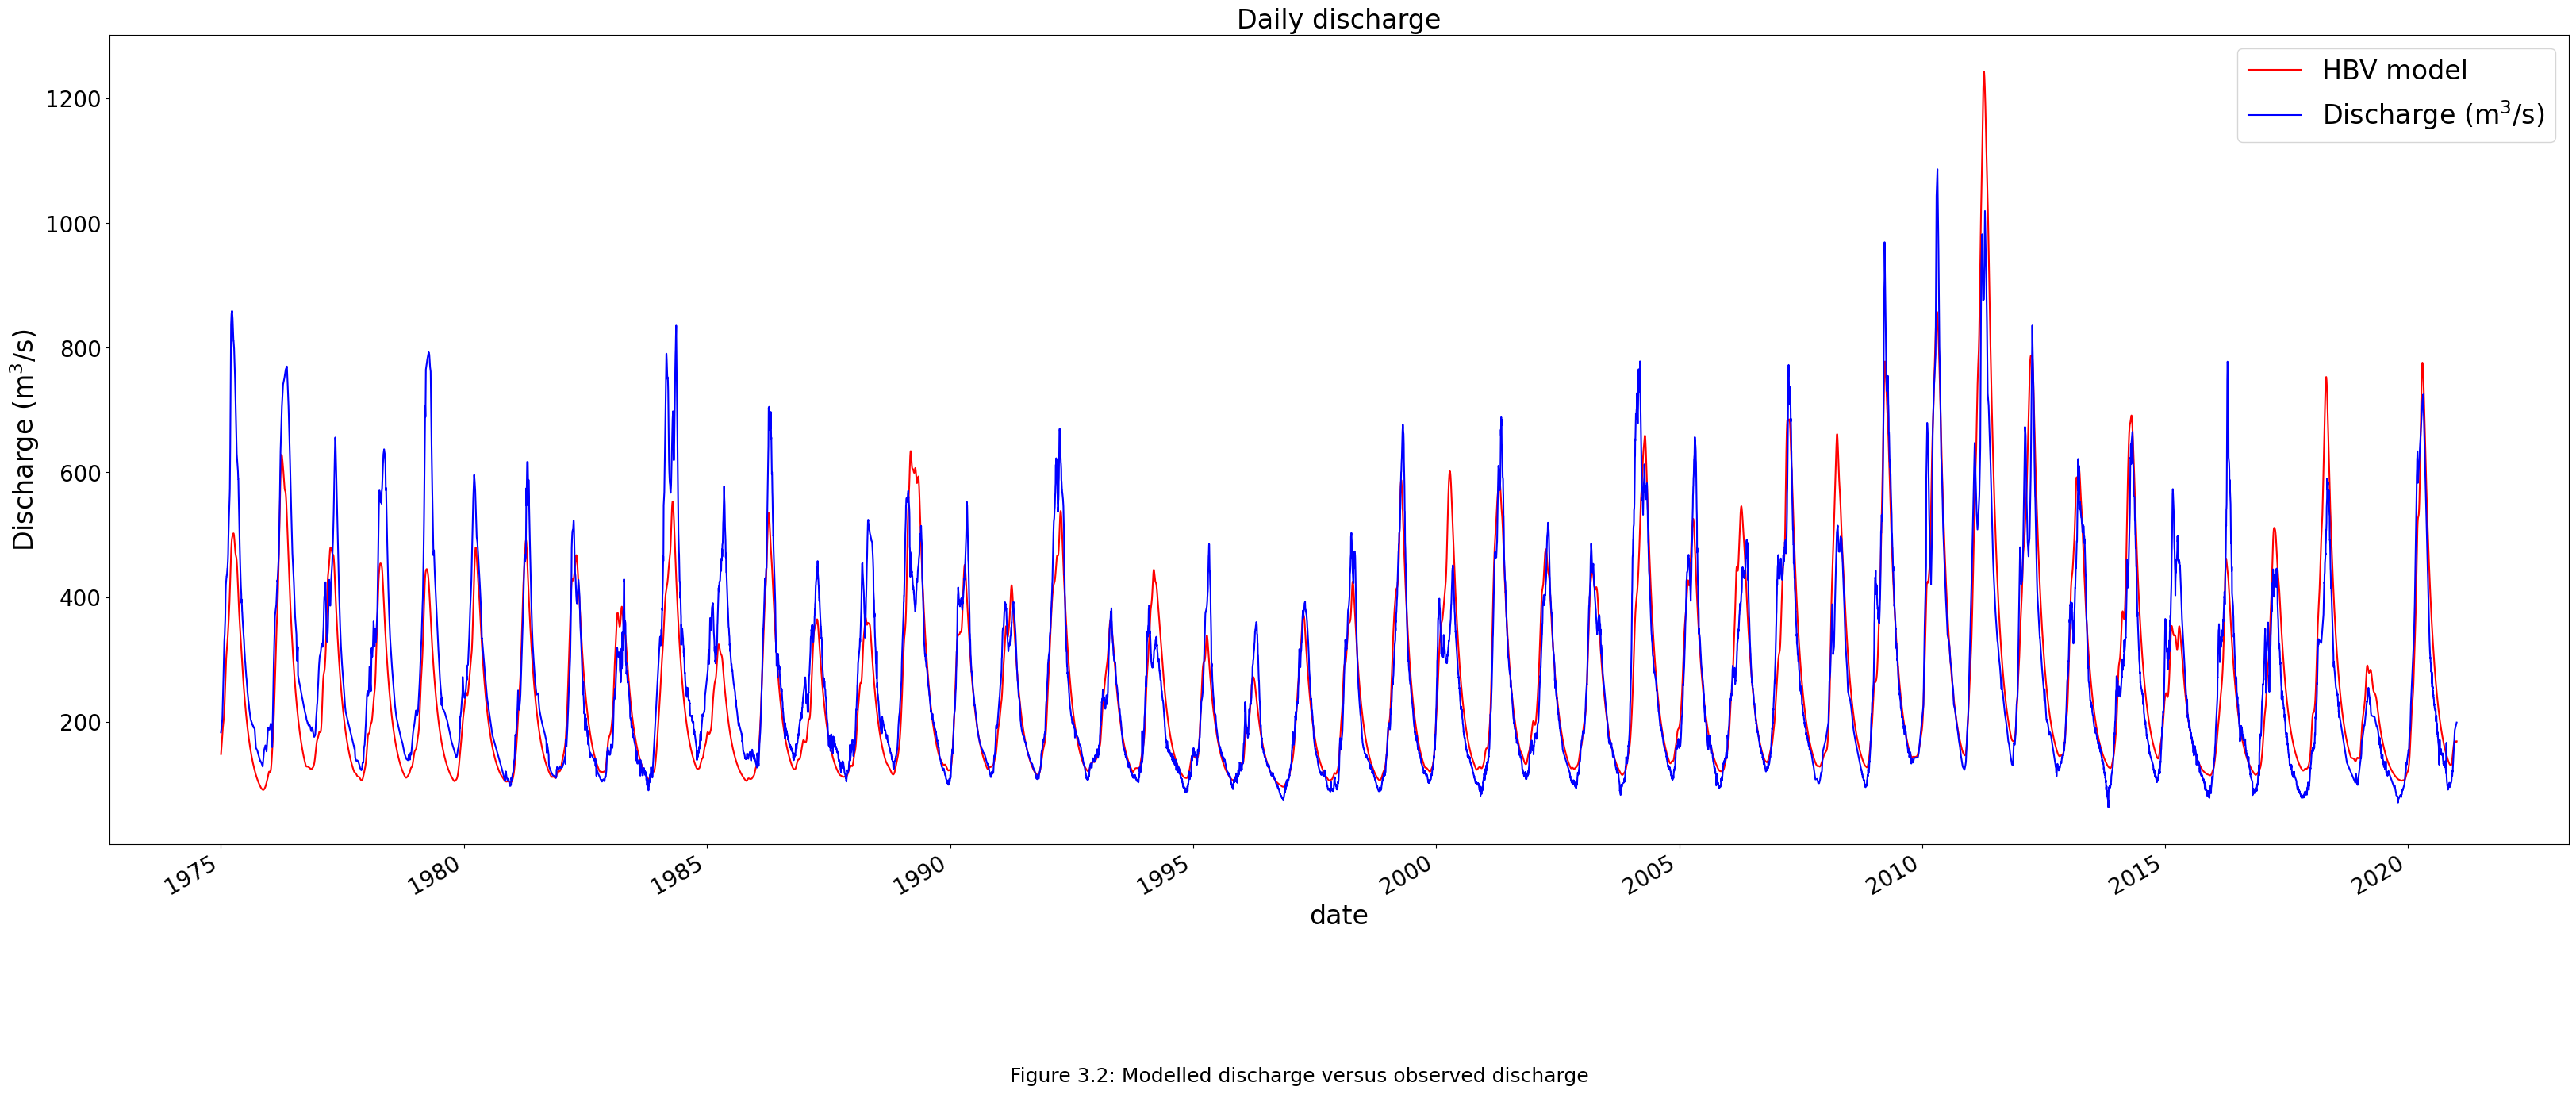

In [4]:
best_parameters = [7.00392414e+00, 4.12282990e-01, 2.24893758e+03, 2.73819672e+00,
       1.84946158e-01, 2.24829623e+01, 1.49246751e-02, 6.55485347e-04,
       3.72295856e-01]

#Storages       Si,  Su,  Sf, Ss, Sp 
s_0 = np.array([0,  100,  0,  5,  0])

#Running the HBV model
model = ewatercycle.models.HBV(forcing=ERA5_forcing)
config_file, _ = model.setup(parameters=best_parameters, initial_storage=s_0)
model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

#Converting data from mm/day to m^3/s
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")

#Plotting results
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m$^3$/s)", fontsize=24)
Q_model_pd['1975'::].plot(ax=ax, color='red') #Removing the spin-up period from the plot
data_daily.plot(ax=ax, color='blue')
plt.legend(fontsize=24)
plt.title('Daily discharge', fontsize=24)
fig.text(0.5, 0,"Figure 3.2: Modelled discharge versus observed discharge", ha="center", fontsize=18);

#Calculating objective value for calibration period, validation period and whole timeframe
obj_value_calibration = objective(Q_model_pd, data_daily['Discharge (m$^3$/s)'], 
                          "1975-01-01T00:00:00Z", "2010-12-31T00:00:00Z", 0.7, 0.3)
obj_value_validation = objective(Q_model_pd, data_daily['Discharge (m$^3$/s)'], 
                          "2010-01-01T00:00:00Z", "2020-12-31T00:00:00Z", 0.7, 0.3)
obj_value_whole_timeframe = objective(Q_model_pd, data_daily['Discharge (m$^3$/s)'], 
                          "1975-01-01T00:00:00Z", "2020-12-31T00:00:00Z", 0.7, 0.3)

Figure 3.3 shows the modelled yearly volume compared to the observed data. In table 3.3, the different percentiles of the yearly volumes – that were used to categorize the droughts – are shown for the modelled and observed data.

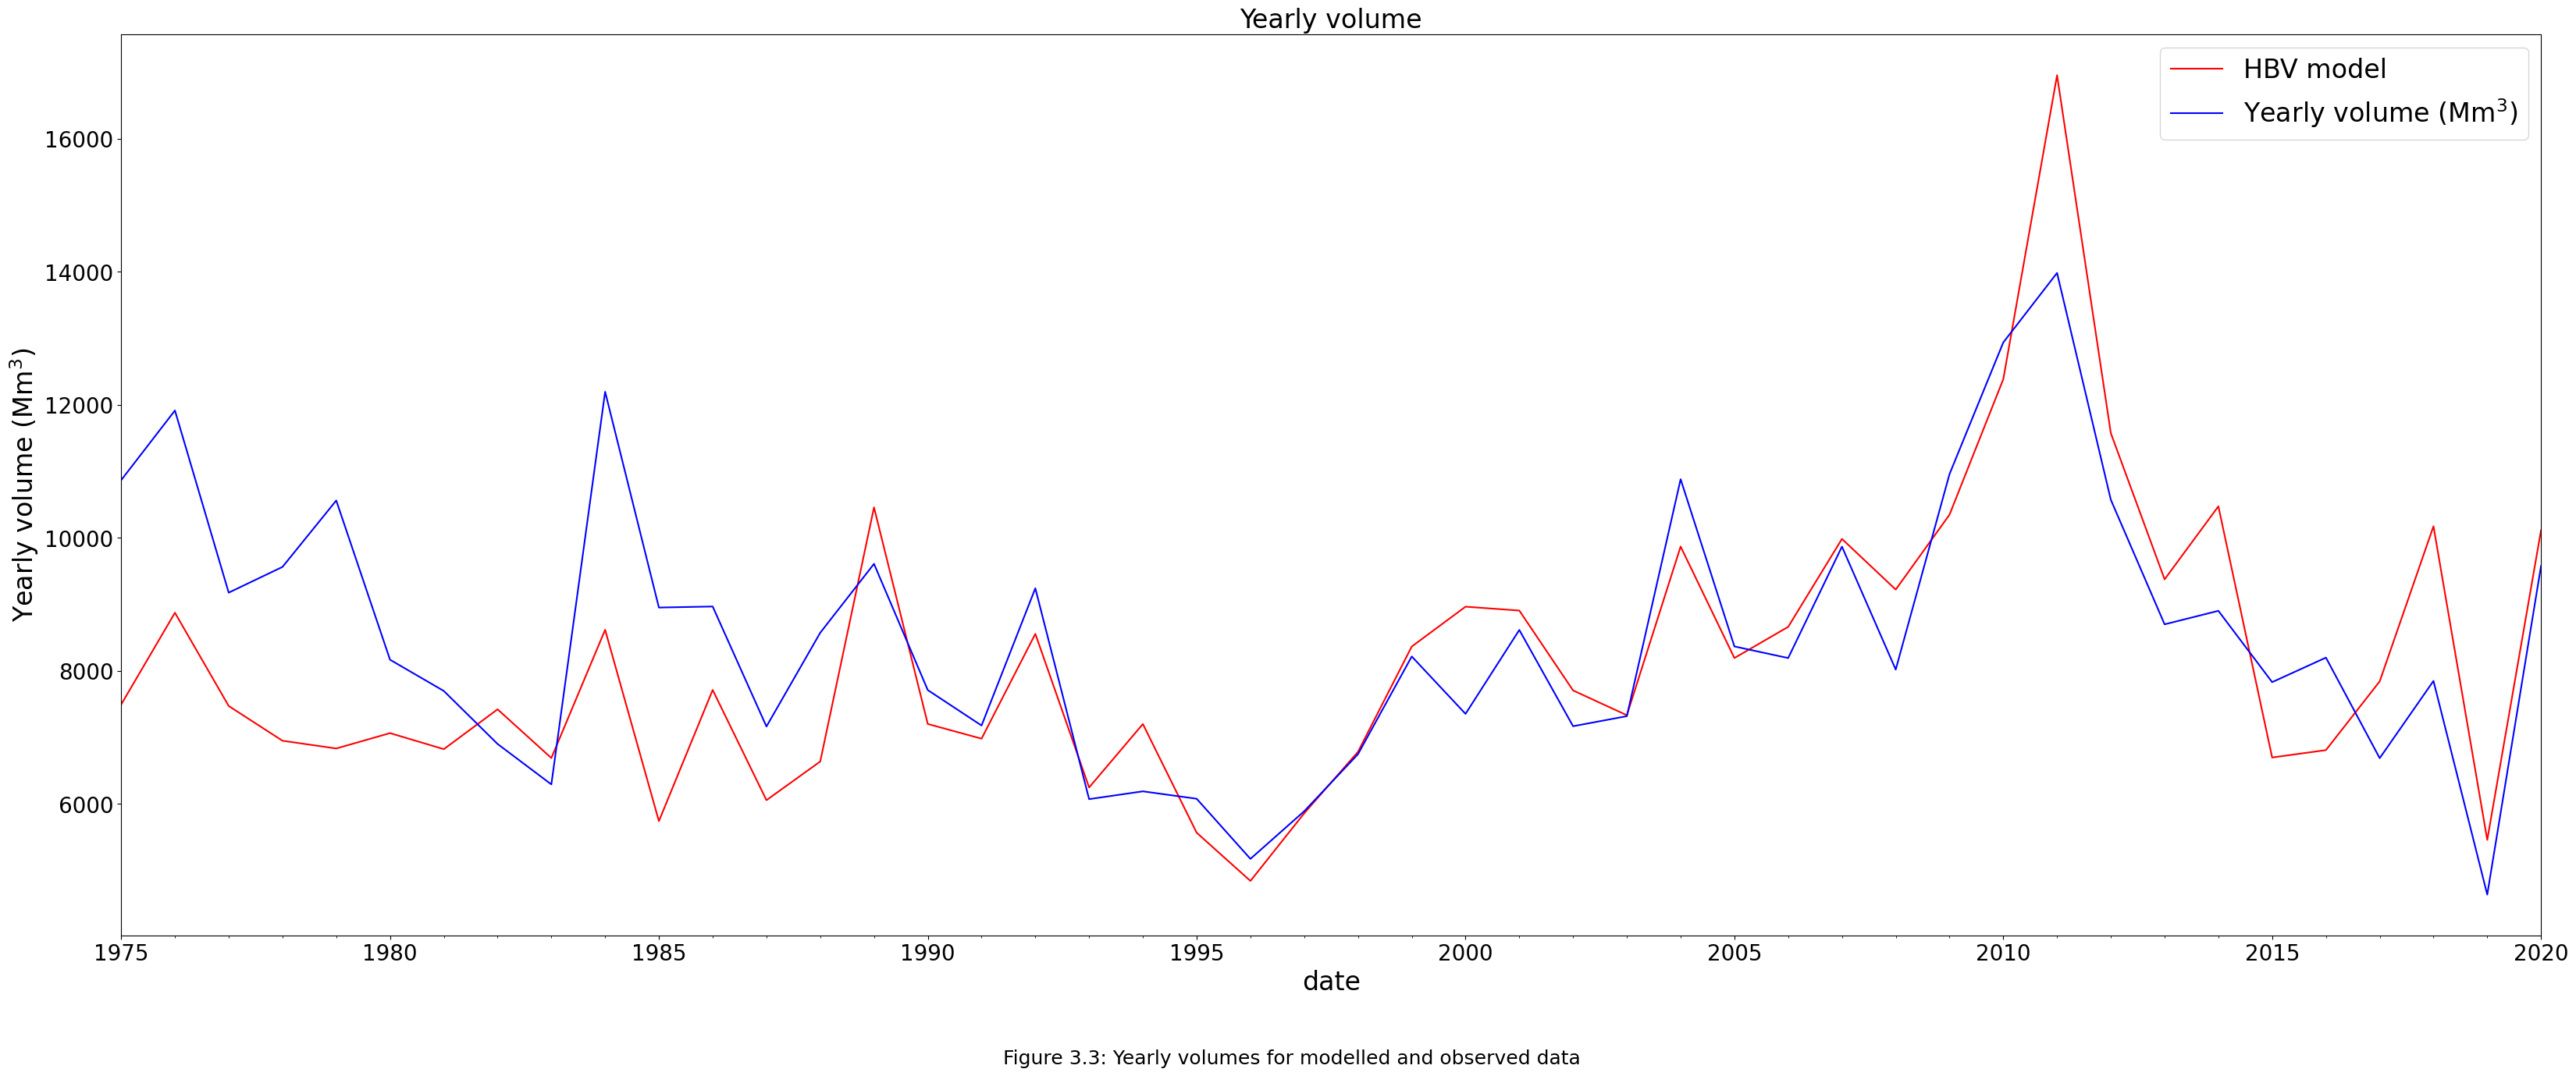

In [5]:
#Converting daily discharge in m^3/s to yearly volumes in Mm^3
Q_model_pd_volume = (Q_model_pd * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.columns = ['Yearly volume (Mm$^3$)']

#Plotting results
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm$^3$)", fontsize=24)
Q_model_pd_volume['1975'::].plot(ax=ax, color='red') #Removing the spin-up period from the plot
yearly_volume.plot(ax=ax, color='blue')
plt.legend(fontsize=24)
plt.title('Yearly volume', fontsize=24)
fig.text(0.5, 0,"Figure 3.3: Yearly volumes for modelled and observed data", ha="center", fontsize=18);

In [6]:
#Removing the spin-up period
Q_model_pd_volume = Q_model_pd_volume[~Q_model_pd_volume.index.year.isin([1970, 1971, 1972, 1973, 1974])]

#Calculating percentiles modelled data
percentile15 = np.percentile(Q_model_pd_volume, 15)
percentile10 = np.percentile(Q_model_pd_volume, 10)
percentile5 = np.percentile(Q_model_pd_volume, 5)

|**Percentile**       |**Modelled (Mm$^3$)**              |**Observed (Mm$^3$)**            |
|---------------------|-----------------------------------|---------------------------------|
|Q15                  |5959 - 6542                        |6135 - 6591                      |
|Q10                  |5613 - 5959                        |5937 - 6135                      |
|Q5                   |< 5613                             |< 5937                           |

<div align="center">
<i>Table 3.2 Calibrated parameters</i>
</div>

In conclusion, the HBV model is a good fit for modelling the Okavango River. The values of using both the KGE and log-NSE method are close to one, which is an indication of a good performing model. Also, the 5th, 10th and 15th percentiles of low yearly volumes are in line with the observed values. 